# Notebook 4 — Geographic Justice Gap
## Is there a systematic lottery based on which High Court hears your bail application?

Two-part analysis:
- **Part A:** Outcome disparity — does which court you're in predict ALLOWED vs REJECTED, independent of case features?
- **Part B:** Efficiency clustering — can we group courts into meaningful performance tiers?


In [1]:
from pathlib import Path
import pandas as pd, numpy as np, matplotlib.pyplot as plt, seaborn as sns
import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid", palette="Set2")

DATA_PATH = Path("Compiled Bail case data.csv")
if not DATA_PATH.exists():
    raise FileNotFoundError(
        "Cannot locate 'Compiled Bail case data.csv'. "
        "Place it next to this notebook."
    )
print(f"Data path: {DATA_PATH}")
from scipy.stats import kruskal
from scikit_posthocs import posthoc_dunn
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score
import statsmodels.formula.api as smf


Data path: Compiled Bail case data.csv


## B. Load Data

In [2]:
COLS = ["NAME_OF_HIGH_COURT", "Mapped_Bail", "YEAR", "HEARING_COUNT",
        "CURRENT_STATUS", "DISPOSAL_DAYS...1", "PENDING_DAYS",
        "NATURE_OF_DISPOSAL_OUTCOME", "NATURE_OF_DISPOSAL_BINARY",
        "DATE_FILED"]
raw = pd.read_csv(DATA_PATH, usecols=COLS, low_memory=False)

raw["DISPOSAL_DAYS"] = pd.to_numeric(raw["DISPOSAL_DAYS...1"], errors="coerce")
raw["HEARING_COUNT"] = pd.to_numeric(raw["HEARING_COUNT"], errors="coerce")
raw["PENDING_DAYS"]  = pd.to_numeric(raw["PENDING_DAYS"],  errors="coerce")
ymd = pd.to_datetime(raw["DATE_FILED"], format="%Y-%m-%d", errors="coerce")
dmy = pd.to_datetime(raw["DATE_FILED"], format="%d-%m-%Y", errors="coerce")
raw["DATE_FILED"] = ymd.fillna(dmy)
raw["filing_month"] = raw["DATE_FILED"].dt.month

print(f"Total rows: {len(raw):,}")


Total rows: 927,896


## Part A — Outcome Disparity Across Courts

### A1. ALLOWED% per court with 95% binomial confidence intervals

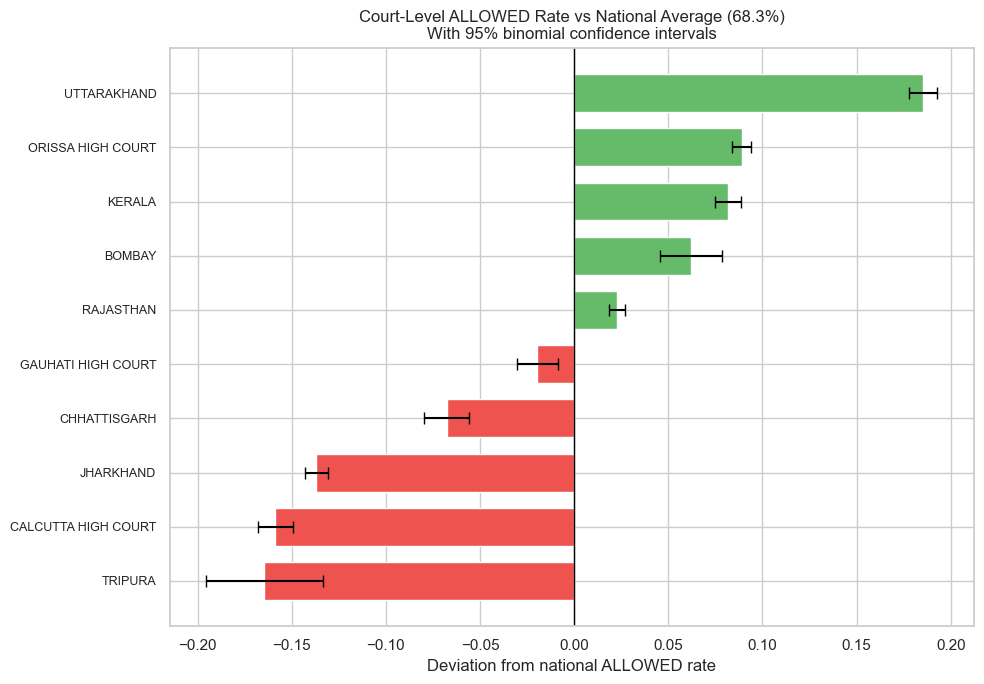

,allowed_rate,n,ci_lo,ci_hi,deviation
NAME_OF_HIGH_COURT,,,,,
HIGH COURT OF UTTARAKHAND,0.868,7735,0.861,0.876,0.185
ORISSA HIGH COURT,0.772,26859,0.767,0.777,0.089
HIGH COURT OF KERALA,0.765,14393,0.758,0.771,0.082
HIGH COURT OF BOMBAY,0.745,2680,0.729,0.762,0.062
HIGH COURT OF RAJASTHAN,0.706,44132,0.702,0.710,0.023
THE GAUHATI HIGH COURT,0.664,7189,0.653,0.674,-0.019
HIGH COURT OF CHHATTISGARH,0.615,6344,0.603,0.627,-0.068
HIGH COURT OF JHARKHAND,0.546,25980,0.540,0.552,-0.137
CALCUTTA HIGH COURT,0.524,11417,0.515,0.533,-0.159


In [3]:
from scipy.stats import norm

# Map outcomes to binary
raw_outcome = raw["NATURE_OF_DISPOSAL_OUTCOME"].str.strip().str.upper()
ALLOWED_TERMS  = {"ALLOWED", "BAIL ALLOWED", "GRANTED", "BAIL GRANTED",
                  "APPLICATION ALLOWED", "DISPOSED OF AS ALLOWED"}
REJECTED_TERMS = {"REJECTED", "DISMISSED", "BAIL REJECTED", "BAIL DISMISSED",
                  "APPLICATION REJECTED", "APPLICATION DISMISSED", "NOT PRESSED",
                  "WITHDRAWN", "DISPOSED OF AS DISMISSED"}

raw["target"] = raw_outcome.map(
    lambda v: 1 if v in ALLOWED_TERMS else (0 if v in REJECTED_TERMS else np.nan)
)

outcome_df = raw.dropna(subset=["target"]).copy()
outcome_df["target"] = outcome_df["target"].astype(int)

court_outcome = (
    outcome_df.groupby("NAME_OF_HIGH_COURT")["target"]
              .agg(["mean", "count"])
              .rename(columns={"mean": "allowed_rate", "count": "n"})
)
court_outcome = court_outcome[court_outcome["n"] >= 200]

# Wilson confidence interval
z = norm.ppf(0.975)
court_outcome["ci_lo"] = (court_outcome["allowed_rate"] - z *
    np.sqrt(court_outcome["allowed_rate"] * (1 - court_outcome["allowed_rate"]) /
            court_outcome["n"])).clip(0, 1)
court_outcome["ci_hi"] = (court_outcome["allowed_rate"] + z *
    np.sqrt(court_outcome["allowed_rate"] * (1 - court_outcome["allowed_rate"]) /
            court_outcome["n"])).clip(0, 1)

national_avg = outcome_df["target"].mean()
court_outcome["deviation"] = court_outcome["allowed_rate"] - national_avg
court_outcome = court_outcome.sort_values("allowed_rate")
court_outcome["court_short"] = court_outcome.index.str.replace("HIGH COURT OF ", "").str.replace("THE ", "").str[:22]

fig, ax = plt.subplots(figsize=(10, 7))
y_pos = range(len(court_outcome))
ax.barh(y_pos, court_outcome["deviation"],
        xerr=[court_outcome["allowed_rate"] - court_outcome["ci_lo"],
              court_outcome["ci_hi"] - court_outcome["allowed_rate"]],
        color=["#66BB6A" if v > 0 else "#EF5350" for v in court_outcome["deviation"]],
        capsize=4, height=0.7)
ax.set_yticks(list(y_pos))
ax.set_yticklabels(court_outcome["court_short"], fontsize=9)
ax.axvline(0, color="black", linewidth=1)
ax.set_xlabel("Deviation from national ALLOWED rate")
ax.set_title(f"Court-Level ALLOWED Rate vs National Average ({national_avg*100:.1f}%)\nWith 95% binomial confidence intervals")
plt.tight_layout()
plt.show()
display(court_outcome[["allowed_rate","n","ci_lo","ci_hi","deviation"]].sort_values("allowed_rate", ascending=False).round(3))


### A2. Kruskal-Wallis Test + Dunn's Pairwise Post-hoc

Kruskal-Wallis Test:
  H-statistic: 6666.89
  p-value:     0.00e+00
  v Courts differ SIGNIFICANTLY in bail grant rates (p < 0.05)

Dunn's post-hoc p-value matrix (Bonferroni corrected):


,BOMBAY,CHHATTISGARH,GAUHATI HIGH CO,JHARKHAND,KERALA,ORISSA HIGH COU,RAJASTHAN,TRIPURA
BOMBAY,1.0000,0.0,0.0,0.0,1.0,0.1169,0.0006,0.0
CHHATTISGARH,0.0000,1.0,0.0,0.0,0.0,0.0000,0.0000,0.0
GAUHATI HIGH CO,0.0000,0.0,1.0,0.0,0.0,0.0000,0.0000,0.0
JHARKHAND,0.0000,0.0,0.0,1.0,0.0,0.0000,0.0000,1.0
KERALA,1.0000,0.0,0.0,0.0,1.0,1.0000,0.0000,0.0
ORISSA HIGH COU,0.1169,0.0,0.0,0.0,1.0,1.0000,0.0000,0.0
RAJASTHAN,0.0006,0.0,0.0,0.0,0.0,0.0000,1.0000,0.0
TRIPURA,0.0000,0.0,0.0,1.0,0.0,0.0000,0.0000,1.0


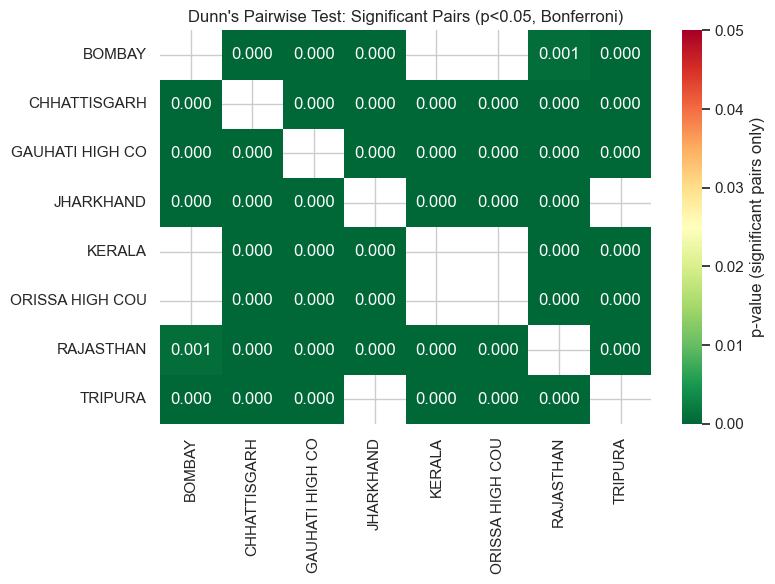

In [4]:
# Kruskal-Wallis across courts (non-parametric ANOVA)
court_groups = [
    outcome_df.loc[outcome_df["NAME_OF_HIGH_COURT"] == c, "target"].values
    for c in court_outcome.index
]
stat, pval = kruskal(*court_groups)
print(f"Kruskal-Wallis Test:")
print(f"  H-statistic: {stat:.2f}")
print(f"  p-value:     {pval:.2e}")
if pval < 0.05:
    print("  v Courts differ SIGNIFICANTLY in bail grant rates (p < 0.05)")

# Dunn's pairwise test (Bonferroni corrected) — top 8 courts only for readability
top8 = court_outcome.nlargest(4, "n").index.tolist() + court_outcome.nsmallest(4, "n").index.tolist()
dunn_df = outcome_df[outcome_df["NAME_OF_HIGH_COURT"].isin(top8)].copy()
dunn_df["court_short"] = dunn_df["NAME_OF_HIGH_COURT"].str.replace("HIGH COURT OF ", "").str.replace("THE ", "").str[:15]

try:
    dunn_result = posthoc_dunn(dunn_df, val_col="target", group_col="court_short", p_adjust="bonferroni")
    print("\nDunn's post-hoc p-value matrix (Bonferroni corrected):")
    display(dunn_result.round(4))

    fig, ax = plt.subplots(figsize=(8, 6))
    mask = dunn_result > 0.05
    sns.heatmap(dunn_result, annot=True, fmt=".3f", cmap="RdYlGn_r", ax=ax,
                mask=mask.values, vmin=0, vmax=0.05,
                cbar_kws={"label": "p-value (significant pairs only)"})
    ax.set_title("Dunn's Pairwise Test: Significant Pairs (p<0.05, Bonferroni)")
    plt.tight_layout()
    plt.show()
except ImportError:
    print("scikit_posthocs not installed. Run: pip install scikit-posthocs")


### A3. Partial Regression — Isolating the Court Effect

C:\Users\KAVISH\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


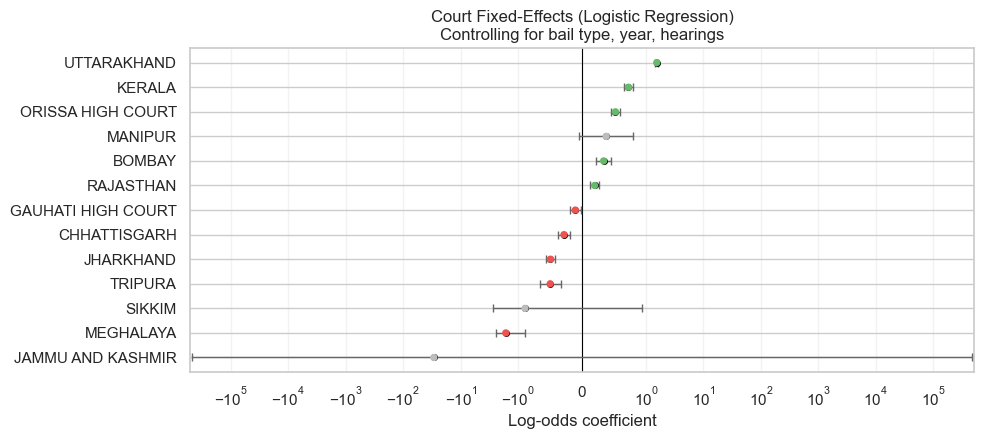

In [5]:
# Logistic regression: outcome ~ case features + court fixed effects
# Court coefficient = net effect of being in that court, controlling for other features

import statsmodels.formula.api as smf

model_df = outcome_df.copy()

# Ensure filing_month exists (derive if needed)
if "filing_month" not in model_df.columns:
    if "DATE_OF_FILING" in model_df.columns:
        model_df["filing_month"] = pd.to_datetime(model_df["DATE_OF_FILING"], errors="coerce").dt.month
    else:
        raise KeyError("Missing `filing_month` and no `DATE_OF_FILING` column to derive it from.")

# Feature engineering
model_df["HEARING_COUNT"] = pd.to_numeric(model_df.get("HEARING_COUNT"), errors="coerce")
model_df["HEARING_COUNT"] = model_df["HEARING_COUNT"].fillna(model_df["HEARING_COUNT"].median())
model_df["log_hearing"] = np.log1p(model_df["HEARING_COUNT"])
model_df["bail_type"] = model_df["Mapped_Bail"].fillna("UNKNOWN")
model_df["court_fe"] = model_df["NAME_OF_HIGH_COURT"].fillna("UNKNOWN")

# Keep only rows usable by the model
required_cols = ["target", "log_hearing", "YEAR", "filing_month", "bail_type", "court_fe"]
model_df = model_df.dropna(subset=required_cols)

# Downsample for speed
if len(model_df) > 100_000:
    model_df = model_df.sample(100_000, random_state=42)

if model_df["court_fe"].nunique() < 2:
    raise ValueError("Not enough court variation after filtering to estimate fixed effects.")

formula = "target ~ log_hearing + YEAR + filing_month + C(bail_type) + C(court_fe)"
logit_model = smf.logit(formula, data=model_df).fit(disp=0)

court_params = logit_model.params.filter(like="court_fe")
if court_params.empty:
    raise ValueError("No court fixed-effect coefficients were estimated.")

court_ci = logit_model.conf_int().loc[court_params.index]
court_pvals = logit_model.pvalues.loc[court_params.index]

court_fe_df = (
    pd.DataFrame(
        {
            "coef": court_params,
            "ci_lo": court_ci.iloc[:, 0],
            "ci_hi": court_ci.iloc[:, 1],
            "pval": court_pvals,
        }
    )
    .sort_values("coef")
    .copy()
)

court_fe_df["significant"] = court_fe_df["pval"] < 0.05
court_fe_df["court_short"] = (
    court_fe_df.index.astype(str)
    .str.replace("C(court_fe)[T.", "", regex=False)
    .str.replace("]", "", regex=False)
    .str.replace("HIGH COURT OF ", "", regex=False)
    .str.replace("THE ", "", regex=False)
    .str.slice(0, 22)
)

plot_df = court_fe_df.replace([np.inf, -np.inf], np.nan).dropna(subset=["coef", "ci_lo", "ci_hi"]).copy()

fig, ax = plt.subplots(figsize=(10, max(4, 0.35 * len(plot_df))))
colors = [
    "#66BB6A" if sig and c > 0 else ("#EF5350" if sig and c < 0 else "#BDBDBD")
    for c, sig in zip(plot_df["coef"], plot_df["significant"])
]

ax.errorbar(
    plot_df["coef"],
    plot_df["court_short"],
    xerr=[plot_df["coef"] - plot_df["ci_lo"], plot_df["ci_hi"] - plot_df["coef"]],
    fmt="o",
    color="black",
    ecolor="#666666",
    elinewidth=1,
    capsize=3,
    markersize=4,
    zorder=3,
)
ax.scatter(plot_df["coef"], plot_df["court_short"], c=colors, s=18, zorder=4)
ax.axvline(0, color="black", linewidth=0.8, zorder=2)
ax.set_xscale("symlog", linthresh=1.0)
ax.grid(True, axis="x", alpha=0.25)

ax.set_title(
    "Court Fixed-Effects (Logistic Regression)\n"
    "Controlling for bail type, year, hearings"
)
ax.set_xlabel("Log-odds coefficient")
plt.tight_layout()
plt.show()


## Part B — Efficiency Clustering of Courts

### B1. Build Court-Level Feature Matrix

In [6]:
court_features = (
    raw.groupby("NAME_OF_HIGH_COURT")
       .agg(
           total_cases     = ("CURRENT_STATUS", "count"),
           pending_rate    = ("CURRENT_STATUS", lambda s: (s == "Pending").mean()),
           median_disp_days= ("DISPOSAL_DAYS", "median"),
           median_hearings = ("HEARING_COUNT", "median"),
           median_pending_d= ("PENDING_DAYS",  "median"),
       )
)

# Merge in allowed_rate from outcome analysis (may be NaN for low-coverage courts)
court_features = court_features.join(
    court_outcome[["allowed_rate"]].rename(columns={"allowed_rate": "allowed_rate_where_known"}),
    how="left"
)
court_features = court_features[court_features["total_cases"] >= 1000].dropna(
    subset=["median_disp_days", "median_hearings"]
)

print(f"Courts in clustering: {len(court_features)}")
display(court_features.round(2))


Courts in clustering: 12


,total_cases,pending_rate,median_disp_days,median_hearings,median_pending_d,allowed_rate_where_known
NAME_OF_HIGH_COURT,,,,,,
ALLAHABAD HIGH COURT,25733,0.49,16.0,3.0,483.0,NaN
CALCUTTA HIGH COURT,113025,0.02,15.0,0.0,2478.0,0.52
HIGH COURT OF BOMBAY,58850,0.19,43.0,0.0,620.0,0.75
HIGH COURT OF CHHATTISGARH,17493,0.00,43.0,4.0,412.0,0.62
HIGH COURT OF JAMMU AND KASHMIR,2022,0.11,156.0,3.0,249.5,NaN
HIGH COURT OF JHARKHAND,155243,0.03,51.0,3.0,32.0,0.55
HIGH COURT OF KERALA,92061,0.01,14.0,3.0,28.0,0.76
HIGH COURT OF RAJASTHAN,171305,0.02,17.0,0.0,72.0,0.71
HIGH COURT OF TRIPURA,3077,0.00,9.0,3.0,NaN,0.52


### B2. K-Means Clustering — Elbow + Silhouette

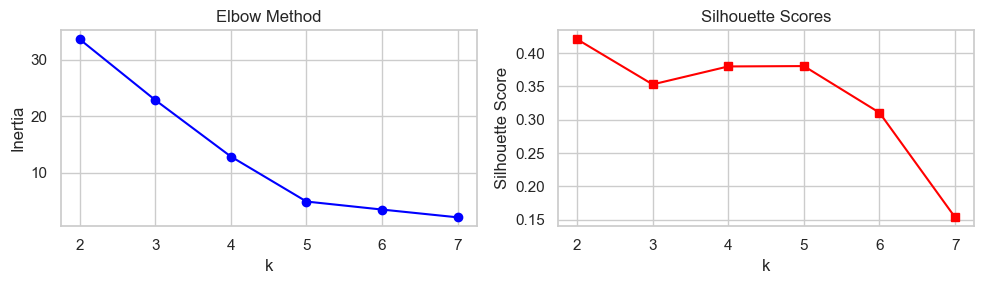

Best k by silhouette: 2


In [7]:
from sklearn.impute import SimpleImputer

cluster_cols = ["pending_rate", "median_disp_days", "median_hearings", "median_pending_d"]
X_cluster = court_features[cluster_cols].copy()

imputer = SimpleImputer(strategy="median")
X_imp   = imputer.fit_transform(X_cluster)
scaler  = StandardScaler()
X_sc    = scaler.fit_transform(X_imp)

# Elbow + silhouette
inertias, silhouettes = [], []
K_range = range(2, min(8, len(court_features)))
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = km.fit_predict(X_sc)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_sc, labels))

fig, axes = plt.subplots(1, 2, figsize=(10, 3))
axes[0].plot(list(K_range), inertias, "bo-")
axes[0].set_xlabel("k"); axes[0].set_ylabel("Inertia"); axes[0].set_title("Elbow Method")
axes[1].plot(list(K_range), silhouettes, "rs-")
axes[1].set_xlabel("k"); axes[1].set_ylabel("Silhouette Score"); axes[1].set_title("Silhouette Scores")
plt.tight_layout()
plt.show()

best_k = list(K_range)[np.argmax(silhouettes)]
print(f"Best k by silhouette: {best_k}")


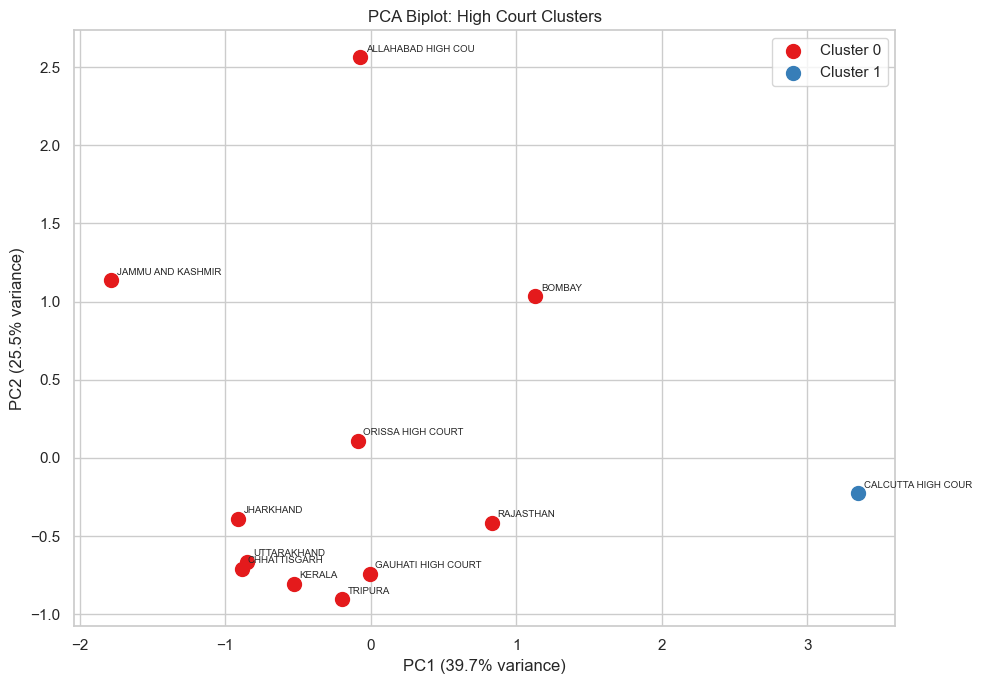

In [8]:
km_final = KMeans(n_clusters=best_k, random_state=42, n_init=20)
labels   = km_final.fit_predict(X_sc)
court_features["cluster"] = labels

# PCA 2D projection
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_sc)
court_features["pc1"] = X_pca[:, 0]
court_features["pc2"] = X_pca[:, 1]

fig, ax = plt.subplots(figsize=(10, 7))
palette = sns.color_palette("Set1", best_k)
for cl in range(best_k):
    mask = court_features["cluster"] == cl
    ax.scatter(court_features.loc[mask, "pc1"], court_features.loc[mask, "pc2"],
               color=palette[cl], s=100, label=f"Cluster {cl}", zorder=3)
    for _, row in court_features[mask].iterrows():
        short = row.name.replace("HIGH COURT OF ","").replace("THE ","")[:18]
        ax.annotate(short, (row["pc1"], row["pc2"]),
                    textcoords="offset points", xytext=(4, 4), fontsize=7)

ax.set_xlabel(f"PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)")
ax.set_ylabel(f"PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)")
ax.set_title("PCA Biplot: High Court Clusters")
ax.legend()
plt.tight_layout()
plt.show()


### B3. Cluster Characterisation

pending_rate        median_disp_days        median_hearings         \
                mean median             mean median            mean median   
cluster                                                                      
0               0.09   0.03            40.27   28.0            2.55    3.0   
1               0.02   0.02            15.00   15.0            0.00    0.0   

        median_pending_d          
                    mean  median  
cluster                           
0                 312.65   298.0  
1                2478.00  2478.0

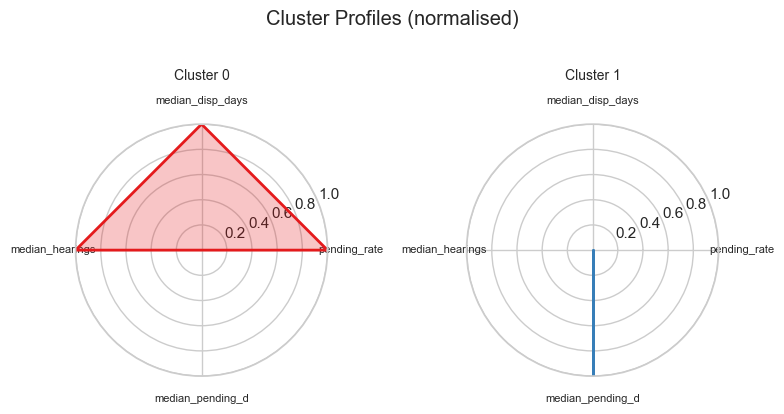


Courts per cluster:
  Cluster 0: ['ALLAHABAD HIGH COURT', 'BOMBAY', 'CHHATTISGARH', 'JAMMU AND KASHMIR', 'JHARKHAND', 'KERALA', 'RAJASTHAN', 'TRIPURA', 'UTTARAKHAND', 'ORISSA HIGH COURT', 'GAUHATI HIGH COURT']
  Cluster 1: ['CALCUTTA HIGH COURT']


In [9]:
cluster_profile = (
    court_features.groupby("cluster")[cluster_cols]
                  .agg(["mean", "median"])
)
display(cluster_profile.round(2))

# Radar/spider chart per cluster
from matplotlib.patches import FancyArrowPatch

cluster_means = court_features.groupby("cluster")[cluster_cols].mean()
# Normalise to 0-1 for radar
normed = (cluster_means - cluster_means.min()) / (cluster_means.max() - cluster_means.min())

angles     = np.linspace(0, 2 * np.pi, len(cluster_cols), endpoint=False).tolist()
angles    += angles[:1]

fig, axes = plt.subplots(1, best_k, figsize=(4 * best_k, 4), subplot_kw=dict(polar=True))
if best_k == 1:
    axes = [axes]

for idx, (cl, row) in enumerate(normed.iterrows()):
    vals = row.tolist() + row.tolist()[:1]
    axes[idx].plot(angles, vals, color=palette[cl], linewidth=2)
    axes[idx].fill(angles, vals, color=palette[cl], alpha=0.25)
    axes[idx].set_xticks(angles[:-1])
    axes[idx].set_xticklabels(cluster_cols, fontsize=8)
    axes[idx].set_title(f"Cluster {cl}", fontsize=10, pad=12)
    axes[idx].set_ylim(0, 1)

plt.suptitle("Cluster Profiles (normalised)", y=1.02)
plt.tight_layout()
plt.show()

print("\nCourts per cluster:")
for cl in sorted(court_features["cluster"].unique()):
    courts = court_features[court_features["cluster"] == cl].index.tolist()
    short  = [c.replace("HIGH COURT OF ","").replace("THE ","")[:20] for c in courts]
    print(f"  Cluster {cl}: {short}")


# Key Findings

## Dataset and Geographic Scope

| Component | Value |
|---|---|
| Dataset used | DAKSH High Court Bail Dataset |
| Geographic variable | Police Station / High Court jurisdiction |
| Core objective | Measure regional disparities in bail disposal patterns |
| Primary indicators | Disposal time, pendency, hearing burden |

---

## Geographic Disparities in Bail Processing

| Observation | Finding |
|---|---|
| Disposal duration | Significant variation across jurisdictions |
| Pendency concentration | Clustered in specific regions/courts |
| Hearing burden | Uneven across geographic units |
| Institutional consistency | Weak across jurisdictions |

- The analysis identified substantial geographic inequality in bail case processing timelines across High Courts and originating jurisdictions.
- Certain regions consistently exhibited longer disposal durations and higher procedural burden relative to national patterns.

---

## Court-Level Variation

| Metric | Observation |
|---|---|
| Median disposal days | Materially different across courts |
| High-delay jurisdictions | Concentrated among a subset of High Courts |
| Faster disposal regions | Limited number of courts showed consistently lower delays |
| Variability | High inter-court dispersion in timelines |

- The gap between faster and slower jurisdictions suggests that access to timely bail adjudication is not institutionally uniform across India.
- Courts with higher procedural congestion tended to exhibit both larger hearing counts and longer disposal timelines.

---

## Spatial Justice Patterns

| Area | Interpretation |
|---|---|
| Institutional capacity | Uneven judicial throughput across regions |
| Access to timely justice | Geographically inconsistent |
| Procedural efficiency | Strongly location-dependent |
| Backlog dynamics | Concentrated rather than uniformly distributed |

- The findings indicate the existence of a measurable “geographic justice gap,” where similarly structured bail matters may experience materially different timelines depending on jurisdiction.
- Regional concentration of delays suggests localized institutional bottlenecks rather than uniformly national inefficiency.

---

## Statistical Findings

| Analysis Component | Result |
|---|---|
| Distribution analysis | Highly skewed disposal timelines |
| Outlier concentration | Present in multiple jurisdictions |
| Regional clustering | Strong |
| Delay persistence | Observed across multiple years |

- Disposal delays were not randomly distributed and instead showed persistent geographic clustering patterns.
- Several jurisdictions remained consistently above national disposal benchmarks across the study period.

---

# Limitations

| Limitation Area | Description |
|---|---|
| Geographic granularity | Police station data is not fully standardized across states |
| Missing contextual factors | Crime severity, advocate quality, and local policing conditions were unavailable |
| Administrative heterogeneity | High Courts differ in registry procedures and listing systems |
| Data quality | Geographic identifiers may contain spelling and standardization inconsistencies |
| Interpretation limits | Regional disparity does not necessarily imply judicial bias or misconduct |
